In [ ]:
from robot_vlp.config import INTERIM_DATA_DIR, PROCESSED_DATA_DIR, FIGURES_DIR, MODELS_DIR
import pickle
import numpy as np
import keras
import robot_vlp.data.preprocessing as p
import matplotlib.pyplot as plt
import robot_vlp.data_collection.communication as c
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, BatchNormalization, LayerNormalization, Input, Bidirectional, Attention, Add
from tensorflow.keras.models import Model
import kerastuner as kt

from robot_vlp.modeling.rnn import ang_loss_fn

import robot_vlp.data.odometer_path_navigation as pg
import robot_vlp.plots.model_performance_plotting as pp
import robot_vlp.modeling.rnn as rnn

from tensorflow import keras
import tensorflow as tf

%load_ext autoreload
%autoreload 2

import tensorflow as tf
tf.config.set_visible_devices([], 'GPU')




dir = INTERIM_DATA_DIR / 'exp_vive_navigated_paths'

train_files = [

    'exp1_3_high_acc.csv',
    'exp1_4_high_acc.csv',
    'exp1_5_high_acc.csv',
    'exp1_6_high_acc.csv',
    ]
valid_files = [    
    'exp1_7_high_acc.csv',
]



def preprocess_df(df):
    X = df[['vlp_x_hist', 'vlp_y_hist', 'encoder_heading_hist','vlp_heading_hist','vlp_heading_change', 'encoder_heading_change', 'encoder_x_hist','encoder_y_hist']].values
    y = df[['x_hist', 'y_hist','heading_hist']].values
    X_win, y_win, m_win = p.window_data(X, y, y, overlap = 0.999999, window_len = 10)
    return X_win, y_win, m_win


def read_csv_to_train(file_list):
    X_lst = []
    y_lst = []
    m_lst = []

    for filename in file_list:
        file = dir / filename
        df = pd.read_csv(file)
        X_win, y_win, m_win = preprocess_df(df)
        X_lst.append(X_win)
        y_lst.append(y_win)
        m_lst.append(m_win)


    X = np.concatenate(X_lst, axis = 0)
    y = np.concatenate(y_lst, axis = 0)
    m = np.concatenate(m_lst, axis = 0)

    return X, y, m

X_train, y_train, _ = read_csv_to_train(train_files)
X_valid, y_valid, _ = read_csv_to_train(valid_files)


from sklearn.preprocessing import StandardScaler
def fit_scale_windows(X):
    n_samples, window_size, n_features = X.shape
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X.reshape(-1, n_features))
    X_scaled = X_scaled.reshape(n_samples, window_size, n_features)
    return X_scaled, scaler

def transform_windows(X, scaler):
    n_samples, window_size, n_features = X.shape
    X_scaled = scaler.transform(X.reshape(-1, n_features))
    return X_scaled.reshape(n_samples, window_size, n_features)

X_train_scaled, scaler = fit_scale_windows(X_train)
X_valid_scaled = transform_windows(X_valid, scaler)

X_train_scaled = np.nan_to_num(X_train_scaled, nan = 0)
X_valid_scaled = np.nan_to_num(X_valid, nan = 0)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [46]:


# Define a hypermodel function
def build_rnn_model(hp):
    inputs = Input(shape=(None, 8), name='input_layer')
    
    # Hyperparameter: number of recurrent layers (1 to 3)
    num_recurrent_layers = hp.Int("num_recurrent_layers", min_value=1, max_value=3, step=1)
    
    # Hyperparameter: recurrent layer type (LSTM or GRU)
    recurrent_layer_type = hp.Choice("recurrent_layer_type", values=["LSTM", "GRU", "BiLSTM"])
    
    x = inputs
    for i in range(num_recurrent_layers):
        units = hp.Int(f"recurrent_units_{i}", min_value=32, max_value=256, step=32)
        return_sequences = i < (num_recurrent_layers - 1)  # Only return sequences for stacked layers
        
        if recurrent_layer_type == "LSTM":
            layer = LSTM(units, return_sequences=return_sequences, dropout=hp.Float(f"dropout_{i}", 0.0, 0.5, step=0.1), recurrent_dropout=hp.Float(f"recurrent_dropout_{i}", 0.0, 0.5, step=0.1), name=f'lstm_{i}')
        elif recurrent_layer_type == "GRU":
            layer = GRU(units, return_sequences=return_sequences, dropout=hp.Float(f"dropout_{i}", 0.0, 0.5, step=0.1), recurrent_dropout=hp.Float(f"recurrent_dropout_{i}", 0.0, 0.5, step=0.1), name=f'gru_{i}')
        else:
            layer = Bidirectional(LSTM(units, return_sequences=return_sequences, dropout=hp.Float(f"dropout_{i}", 0.0, 0.5, step=0.1), recurrent_dropout=hp.Float(f"recurrent_dropout_{i}", 0.0, 0.5, step=0.1), name=f'bilstm_{i}'))
        
        x = layer(x)
        
        # Optional batch normalization
        if hp.Boolean(f"batch_norm_{i}"):
            x = BatchNormalization()(x)
        
        # Optional layer normalization
        if hp.Boolean(f"layer_norm_{i}"):
            x = LayerNormalization()(x)
        
        # Skip connection
        if i > 0:
            x = Add()([x, prev_x])
        prev_x = x
    
    # Attention Mechanism
    if hp.Boolean("use_attention"):
        x = Attention()([x, x])
    
    # Output layers
    loc_output = Dense(2, activation='linear', name='loc_output')(x)
    angle_output = Dense(2, activation='tanh', name='angle_output')(x)
    
    model = Model(inputs=inputs, outputs=[loc_output, angle_output])
    
    # Hyperparameter: learning rate for optimizer
    lr = hp.Float("lr", min_value=1e-5, max_value=1e-2, sampling="LOG")
    optimizer_choice = hp.Choice("optimizer", values=["adam", "rmsprop", "nadam", "sgd"])
    
    if optimizer_choice == "adam":
        optimizer = keras.optimizers.Adam(learning_rate=lr)
    elif optimizer_choice == "rmsprop":
        optimizer = keras.optimizers.RMSprop(learning_rate=lr)
    elif optimizer_choice == "sgd":
        optimizer = keras.optimizers.SGD(learning_rate=lr, momentum=0.9)
    else:
        optimizer = keras.optimizers.Nadam(learning_rate=lr)
    
    model.compile(
        optimizer=optimizer,
        loss=[keras.losses.Huber(delta=1.0), keras.losses.Huber(delta=1.0)],
        loss_weights={'loc_output': 1.0, 'angle_output': 1.0},
    )
    
    return model

# Set up the tuner
tuner = kt.Hyperband(
    build_rnn_model,
    objective="val_loss",
    max_epochs=50,
    factor=3,
    directory="rnn_tuning",
    project_name="rnn_hyperparam_tuning",
    overwrite=True
)

# Define callbacks
stop_early = keras.callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

# Run the hyperparameter search
tuner.search(
    X_train_scaled, 
    [y_train[:, [0,1]], y_train[:, 2]],
    epochs=50, 
    validation_split=0.2, 
    callbacks=[stop_early, reduce_lr]
)

# Retrieve the best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("Best hyperparameters:")
print(f"  Number of recurrent layers: {best_hps.get('num_recurrent_layers')}")
print(f"  Recurrent layer type: {best_hps.get('recurrent_layer_type')}")
for i in range(best_hps.get("num_recurrent_layers")):
    print(f"  Recurrent Layer {i} units: {best_hps.get(f'recurrent_units_{i}')}")
    print(f"  Batch norm layer {i}: {best_hps.get(f'batch_norm_{i}')}")
    print(f"  Dropout rate layer {i}: {best_hps.get(f'dropout_{i}')}")
print(f"  Learning rate: {best_hps.get('lr')}")
print(f"  Optimizer: {best_hps.get('optimizer')}")

# Build and train the best model
best_model = tuner.hypermodel.build(best_hps)
history = best_model.fit(
    X_train_scaled, 
    [y_train[:, [0,1]], y_train[:, 2]],
    validation_data=(X_valid_scaled, [y_valid[:, [0,1]], y_valid[:, 2]]),
    epochs=300, 
    batch_size=32, 
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True), reduce_lr]
)




Epoch 1/200
208/208 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - angle_output_loss: 0.3204 - loc_output_loss: 0.0414 - loss: 0.3618 - val_angle_output_loss: 0.4835 - val_loc_output_loss: 0.2619 - val_loss: 0.7442
Epoch 2/200
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - angle_output_loss: 0.0457 - loc_output_loss: 0.0012 - loss: 0.0469 - val_angle_output_loss: 0.5972 - val_loc_output_loss: 0.2683 - val_loss: 0.8644
Epoch 3/200
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - angle_output_loss: 0.0196 - loc_output_loss: 7.0405e-04 - loss: 0.0203 - val_angle_output_loss: 0.6548 - val_loc_output_loss: 0.2472 - val_loss: 0.9011
Epoch 4/200
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - angle_output_loss: 0.0177 - loc_output_loss: 6.3065e-04 - loss: 0.0183 - val_angle_output_loss: 0.6846 - val_loc_output_loss: 0.2457 - val_loss: 0.9297
Epoch 5/200
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - angle_output_loss: 0.0169 - loc_output_loss: 5.7235e-04 - loss: 0.0175 - val_angle_output_loss: 0.7080 - val_loc_output_loss

In [ ]:
df = pd.read_csv(dir / 'exp1_8_high_acc.csv')
X_win, y_win, m_win = preprocess_df(df)
df = df.iloc[9:]
df.reset_index(drop = True, inplace = True)

X_win_scaled = transform_windows(X_win ,scaler)

X_win_scaled = np.nan_to_num(X_win_scaled, nan = 0)

pre = model.predict(X_win_scaled)

df[['model_x_hist', 'model_y_hist']] =  pre[0]
df['model_heading_hist'] = p.vector_to_ang(pre[1], unit = 'degrees')

model_pos_errs = np.sqrt(np.square(df['x_hist'] - df['model_x_hist']) + np.square(df['y_hist'] - df['model_y_hist']))
vlp_pos_errs = np.sqrt(np.square(df['x_hist'] - df['vlp_x_hist']) + np.square(df['y_hist'] - df['vlp_y_hist']))
encoder_pos_errs = np.sqrt(np.square(df['x_hist'] - df['encoder_x_hist']) + np.square(df['y_hist'] - df['encoder_y_hist']))

model_heading_err = [c.normalize_angle(a) for a in (df['heading_hist'] - df['model_heading_hist'])]
encoder_heading_err = [c.normalize_angle(a) for a in (df['heading_hist'] - df['encoder_heading_hist'])]
vlp_heading_err = [c.normalize_angle(a) for a in (df['heading_hist'] - df['vlp_heading_hist'])]


print('model mean err: ', np.mean(model_pos_errs))
print('vlp mean err: ', np.mean(vlp_pos_errs))
print('encoder mean err: ', np.mean(encoder_pos_errs))

print('mod_heading_err : ', np.mean(np.abs(model_heading_err )))
print('enc_heading_err: ', np.mean(np.abs(encoder_heading_err)))
print('vlp_heading_err: ', np.mean(np.abs(vlp_heading_err)))

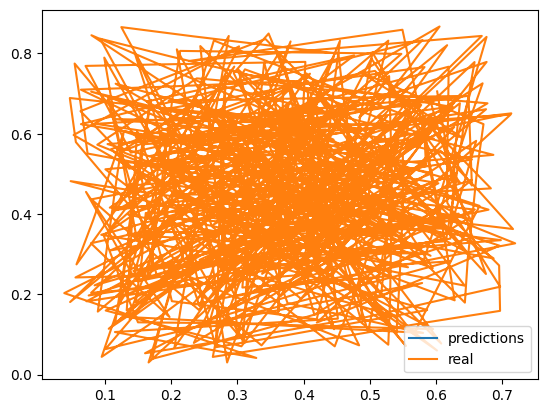

In [58]:
plt.plot(df['model_x_hist'], df['model_y_hist'], label = 'predictions')
plt.plot(df['x_hist'], df['y_hist'], label = 'real')
# plt.plot(df['vlp_x_hist'], df['vlp_y_hist'])


plt.legend()

model mean err:  0.04669627628770833
vlp mean err:  0.03904806570971635
encoder mean err:  0.28843782011705826


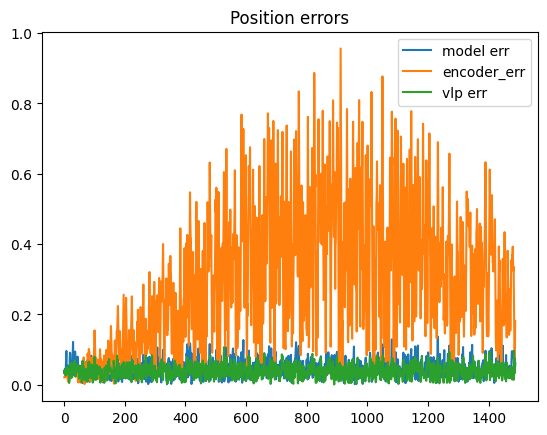

In [45]:
plt.plot(model_pos_errs, label = 'model err')
plt.plot(encoder_pos_errs, label = 'encoder_err')

plt.plot(vlp_pos_errs, label = 'vlp err')
plt.legend()
plt.title('Position errors')


mod_heading_err :  10.827969086231496
enc_heading_err:  91.68510379995637
vlp_heading_err:  12.396867006632844


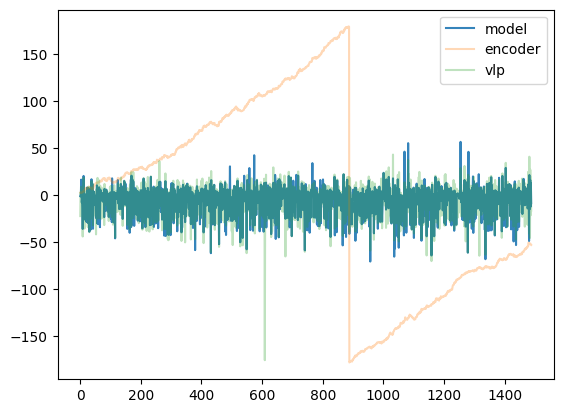

In [46]:
plt.plot(model_heading_err, label = 'model', alpha = 0.9)
plt.plot(encoder_heading_err, label = 'encoder', alpha = 0.3)
plt.plot(vlp_heading_err, label = 'vlp', alpha = 0.3)
plt.legend()

print('mod_heading_err : ', np.mean(np.abs(model_heading_err )))
print('enc_heading_err: ', np.mean(np.abs(encoder_heading_err)))
print('vlp_heading_err: ', np.mean(np.abs(vlp_heading_err)))

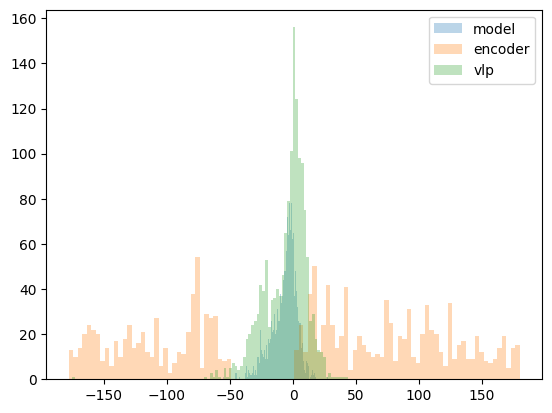

In [38]:
_ = plt.hist(model_heading_err, alpha = 0.3, bins = 100, label = 'model')
_ = plt.hist(encoder_heading_err, alpha = 0.3, bins = 100, label = 'encoder')
_ = plt.hist(vlp_heading_err, alpha = 0.3, bins = 100, label = 'vlp')
plt.legend()